In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# a dataframe
df = pd.read_excel('http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls')

                     Mileage         Price
Mileage                                   
(0, 10000]       5588.629630  24096.714451
(10000, 20000]  15898.496183  21955.979607
(20000, 30000]  24114.407104  20278.606252
(30000, 40000]  33610.338710  19463.670267


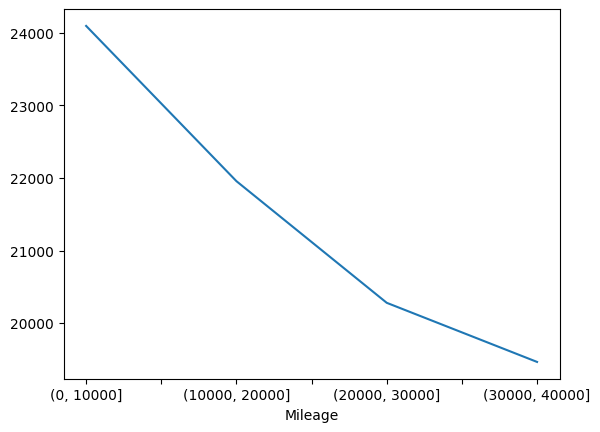

In [8]:
%matplotlib inline
import numpy as np
#idk why we used two different cells maybe its more manageable

# WE take out two columns of df
# the [[]] is part of syntax idk why we need 2 of those
df1 = df[['Mileage','Price']]

# arange takes start,stop and steps as parameters
bins = np.arange(0,50000,10000)
# The reason why the 40000-50000 range did not come is 0 and 50K is not included
# Reduce the step size to 9999 then see the magic 
groups = df1.groupby(pd.cut(df1['Mileage'], bins)).mean()
print(groups.head())
groups['Price'].plot.line()
plt.show()

In [9]:
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
# The reason we create object is because nearly 
# all scikit-learn tools are object oriented
scale = StandardScaler()
# StandardScaler is stateful and needs to 
# learn(not just apply any general formula)


X = df[['Mileage', 'Cylinder', 'Doors']]
y = df['Price']

X[['Mileage', 'Cylinder', 'Doors']] = scale.fit_transform(X[['Mileage', 'Cylinder', 'Doors']].values)

#For Y-Intercept, cars value cant be zero so start somewhere like 10k or smthn
X = sm.add_constant(X)
print(X)

est = sm.OLS(y, X).fit()
print(est.summary())

     const   Mileage  Cylinder     Doors
0      1.0 -1.417485   0.52741  0.556279
1      1.0 -1.305902   0.52741  0.556279
2      1.0 -0.810128   0.52741  0.556279
3      1.0 -0.426058   0.52741  0.556279
4      1.0  0.000008   0.52741  0.556279
..     ...       ...       ...       ...
799    1.0 -0.439853   0.52741  0.556279
800    1.0 -0.089966   0.52741  0.556279
801    1.0  0.079605   0.52741  0.556279
802    1.0  0.750446   0.52741  0.556279
803    1.0  1.932565   0.52741  0.556279

[804 rows x 4 columns]
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     150.0
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           3.95e-77
Time:                        13:36:42   Log-Likelihood:                -8356.7
No. Observ

In [11]:
# calculating mean value of cars compared to their door number
y.groupby(df.Doors).mean()

#Useless predictor as the mean values are not very different
# 2 Doors are generally more expensive but some 4 doors can be also expensive

Doors
2    23807.135520
4    20580.670749
Name: Price, dtype: float64

In [18]:
# use transform() from scale and apply transformation mentioned
# above, here its StandardScalar, data input could be
# (cost, cylinder, doors)
# scaled stores a 2D Matrix after StandardScalar Transformation
scaled = scale.transform([[50000, 8, 4]])

#scaled value is updated to a 1D array where the first row is taken 
# and at the 0th index we insert 1
scaled = np.insert(scaled[0], 0, 1)
print(scaled)

# predicted value of the scaled thingy - i seriously have no idea what the fuck am i doing🤣 
predicted = est.predict(scaled)
print(predicted)


[1.         3.6829755  1.96971667 0.55627894]
[26881.50775098]
